**[1 mark]** Explore the article **[here](https://machinelearningmastery.com/gradient-descent-with-momentum-from-scratch/)** on gradient descent with momentum. Implement gradient descent with momentum for the above two datasets. Visualize the convergence process for 15 steps. Compare the average number of steps taken with gradient descent (both variants full batch and stochastic) with momentum to that of vanilla gradient descent to converge to an $\epsilon$-neighborhood of the minimizer for both datasets. Choose $\epsilon = 0.001$. Write down your observations. Show the contour plots for different epochs for the momentum implementation. Specifically, show all the vectors: the gradient, the current value of $\theta$, momentum, etc.

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import imageio.v2 as imageio

plt.rcParams["figure.dpi"] = 140


DEVICE = "cpu"
EPS = 1e-3                 # ε for convergence: ‖θ_t - θ*‖ < EPS
MAX_STEPS = 100_000
EPOCHS_SHOW = 15           # first 15 steps for momentum
N_RUNS = 20                # averaging for step counts

LR_GD = 1e-2               # vanilla full-batch GD
LR_SGD = 1e-2              # vanilla SGD
LR_MOM_GD = 1e-2           # momentum (full-batch)
LR_MOM_SGD = 1e-2          # momentum (SGD)

MU = 0.9                   # momentum coefficient

OUTDIR = Path("mom_results")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)

PyTorch: 2.8.0+cu126


In [2]:
def make_dataset_1():
    num_samples = 40
    np.random.seed(45)
    x1 = np.random.uniform(-20, 20, num_samples)
    f_x = 100 * x1 + 1
    eps = np.random.randn(num_samples)
    y = f_x + eps
    X = np.stack([np.ones_like(x1), x1], axis=1)  # [1, x]
    return (torch.tensor(X, dtype=torch.float32, device=DEVICE),
            torch.tensor(y, dtype=torch.float32, device=DEVICE))

def make_dataset_2():
    np.random.seed(45)
    num_samples = 40
    x1 = np.random.uniform(-1, 1, num_samples)
    f_x = 3 * x1 + 4
    eps = np.random.randn(num_samples)
    y = f_x + eps
    X = np.stack([np.ones_like(x1), x1], axis=1)
    return (torch.tensor(X, dtype=torch.float32, device=DEVICE),
            torch.tensor(y, dtype=torch.float32, device=DEVICE))

X1, y1 = make_dataset_1()
X2, y2 = make_dataset_2()
print("Dataset1:", X1.shape, y1.shape, "| Dataset2:", X2.shape, y2.shape)


Dataset1: torch.Size([40, 2]) torch.Size([40]) | Dataset2: torch.Size([40, 2]) torch.Size([40])


In [3]:

def true_minimizer(X, y):
    XT = X.t()
    H = XT @ X
    g = XT @ y
    return torch.linalg.solve(H, g)

def mse_loss(theta, X, y):
    yhat = X @ theta
    return F.mse_loss(yhat, y, reduction="mean")

def grad_mse(theta, X, y):
    n = X.shape[0]
    r = (X @ theta) - y
    return (2.0 / n) * (X.t() @ r)


In [4]:

def gd_full_batch(X, y, theta_star, lr=LR_GD, log_steps=EPOCHS_SHOW):
    theta = torch.randn(2, device=DEVICE)
    theta_path = [theta.clone()]
    losses = []
    steps = 0
    snapshots = []

    for ep in range(log_steps):
        g = grad_mse(theta, X, y)
        update = -lr * g
        v = torch.zeros_like(theta)
        snapshots.append(dict(theta=theta.clone(), grad=g.clone(), v=v.clone(), update=update.clone()))
        theta = theta + update
        theta_path.append(theta.clone())
        losses.append(mse_loss(theta, X, y).item())
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    while steps < MAX_STEPS:
        g = grad_mse(theta, X, y)
        theta = theta - lr * g
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    return theta_path, losses, steps, snapshots

def sgd(X, y, theta_star, lr=LR_SGD, log_epochs=EPOCHS_SHOW, seed=123):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    theta = torch.randn(2, device=DEVICE)
    theta_path = [theta.clone()]
    losses = []
    steps = 0
    snapshots = []

    for ep in range(log_epochs):
        idxs = rng.permutation(n)
        for i in idxs:
            xi = X[i]; yi = y[i]
            g = 2.0 * (torch.dot(xi, theta) - yi) * xi
            update = -lr * g
            v = torch.zeros_like(theta)
            if i == idxs[0]:
                snapshots.append(dict(theta=theta.clone(), grad=g.clone(), v=v.clone(), update=update.clone()))
            theta = theta + update
            theta_path.append(theta.clone())
            steps += 1
            if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
                break
        losses.append(mse_loss(theta, X, y).item())
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    rng2 = np.random.default_rng(seed + 999)
    while steps < MAX_STEPS:
        i = int(rng2.integers(0, n))
        xi = X[i]; yi = y[i]
        g = 2.0 * (torch.dot(xi, theta) - yi) * xi
        theta = theta - lr * g
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    return theta_path, losses, steps, snapshots


# **Cell - Optimizers (Momentum GD & Momentum SGD)**

### **Update rule**

The update equations for classical momentum are:

$$
\begin{align*}
\mathbf{v}_t &\leftarrow \mu \mathbf{v}_{t-1} + \alpha \nabla J(\boldsymbol{\theta}_t) \\
\boldsymbol{\theta}_{t+1} &\leftarrow \boldsymbol{\theta}_t - \mathbf{v}_t
\end{align*}
$$

-   $\mu$ = momentum coefficient (e.g., 0.9)
-   $\alpha$ = learning rate (`lr`)
-   $\mathbf{v}_t$ is the **velocity**, which is an exponentially weighted sum of past gradients.



### **1) `gd_momentum_full_batch(X, y, theta_star, lr, mu, log_steps)`**

-   Uses the **full gradient** $\nabla J(\boldsymbol{\theta}) = \frac{2}{n} X^T (X\boldsymbol{\theta} - y)$ at each step.
-   **Tracks:**
    -   `theta_path`: parameters at every step (for animations).
    -   `losses`: MSE per step for the first `log_steps`.
    -   `snapshots`: Dictionaries containing the `current` $\boldsymbol{\theta}$, `gradient` $\mathbf{g}$, `velocity` $\mathbf{v}$, and `update = -v` (for creating vector plots).
-   **Convergence:** Stops when $\|\boldsymbol{\theta} - \boldsymbol{\theta}^*\|_2 < \epsilon$ or `MAX_STEPS` is reached.
-   **Returns:** `(theta_path, losses, steps, snapshots)`.

---

### 2) **`sgd_momentum(X, y, theta_star, lr, mu, log_epochs, seed)`**

-   Uses **per-sample gradients**, $2(\langle \mathbf{x}_i, \boldsymbol{\theta} \rangle - y_i)\mathbf{x}_i$, shuffling indices each epoch.
-   Momentum is updated **every sample**: $\mathbf{v} \leftarrow \mu\mathbf{v} + \alpha\mathbf{g}$, then $\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \mathbf{v}$.
-   Logs the full-batch MSE at **epoch boundaries** and saves a `snapshot` at the start of each epoch for vector visualization.
-   **Convergence:** Same $\epsilon$-test; continues past the visualization horizon to count the total steps-to-$\epsilon$.
-   **Returns:** `(theta_path, losses, steps, snapshots)`.

In [5]:
def gd_momentum_full_batch(X, y, theta_star, lr=LR_MOM_GD, mu=MU, log_steps=EPOCHS_SHOW):
    theta = torch.randn(2, device=DEVICE)
    v = torch.zeros(2, device=DEVICE)
    theta_path = [theta.clone()]
    losses = []
    steps = 0
    snapshots = []

    for ep in range(log_steps):
        g = grad_mse(theta, X, y)
        v = mu * v + lr * g
        update = -v
        snapshots.append(dict(theta=theta.clone(), grad=g.clone(), v=v.clone(), update=update.clone()))
        theta = theta + update
        theta_path.append(theta.clone())
        losses.append(mse_loss(theta, X, y).item())
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    while steps < MAX_STEPS:
        g = grad_mse(theta, X, y)
        v = mu * v + lr * g
        theta = theta - v
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    return theta_path, losses, steps, snapshots

def sgd_momentum(X, y, theta_star, lr=LR_MOM_SGD, mu=MU, log_epochs=EPOCHS_SHOW, seed=456):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    theta = torch.randn(2, device=DEVICE)
    v = torch.zeros(2, device=DEVICE)
    theta_path = [theta.clone()]
    losses = []
    steps = 0
    snapshots = []

    for ep in range(log_epochs):
        idxs = rng.permutation(n)
        xi0 = X[idxs[0]]; yi0 = y[idxs[0]]
        g0 = 2.0 * (torch.dot(xi0, theta) - yi0) * xi0
        snapshots.append(dict(theta=theta.clone(), grad=g0.clone(), v=v.clone(), update=None))

        for i in idxs:
            xi = X[i]; yi = y[i]
            g = 2.0 * (torch.dot(xi, theta) - yi) * xi
            v = mu * v + lr * g
            theta = theta - v
            theta_path.append(theta.clone())
            steps += 1
            if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
                break
        losses.append(mse_loss(theta, X, y).item())
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    while steps < MAX_STEPS:
        i = int(rng.integers(0, n))
        xi = X[i]; yi = y[i]
        g = 2.0 * (torch.dot(xi, theta) - yi) * xi
        v = mu * v + lr * g
        theta = theta - v
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < EPS:
            break

    return theta_path, losses, steps, snapshots


# **Cell - Momentum Contour + Vectors**

**Function:** `contour_with_vectors(X, y, theta_star, snapshots, title="...", fname=None)`



#### **Purpose**
To visualize the **loss surface** in parameter space ($b, w$) and overlay, at selected steps, the key vectors used by the momentum algorithm:
-   Current parameter $\boldsymbol{\theta}$ (red dot)
-   Gradient $\nabla J(\boldsymbol{\theta})$ (green arrow)
-   Velocity / momentum $\mathbf{v}$ (orange arrow)
-   Applied update $-\mathbf{v}$ (purple arrow)


#### **How it works**

**1. Grid & Contours**
-   Builds a grid around the true minimizer $\boldsymbol{\theta}^*$ with a span adapted to the data scale (wider if $|x|$ is large).
-   Computes the MSE on each grid point and draws the corresponding contour lines (level sets).

**2. Selected Steps**
-   Picks specific steps (e.g., `{0, 3, 6, 9, 12, 15}`) from the `snapshots` data if available.
-   For each picked snapshot `s`, it reads:
    -   `s["theta"]` → the point to plot,
    -   `s["grad"]` → draws the gradient vector $\nabla J$ from that point,
    -   `s["v"]` → draws the velocity vector $\mathbf{v}$,
    -   `s["update"]` → draws the update vector (or uses $-\mathbf{v}$ if not present).

**3. Reference**
-   Plots the true minimizer $\boldsymbol{\theta}^*$ as a black ★ for orientation.

In [6]:
def contour_with_vectors(X, y, theta_star, snapshots, title="Momentum (vectors)", fname=None):
    b_star, w_star = theta_star.tolist()
    wide = X[:,1].abs().max().item() > 1.5
    b_span = 50.0 if wide else 6.0
    w_span = 150.0 if wide else 6.0
    b_vals = np.linspace(b_star - b_span, b_star + b_span, 220)
    w_vals = np.linspace(w_star - w_span, w_star + w_span, 220)
    B, W = np.meshgrid(b_vals, w_vals)
    loss_grid = np.zeros_like(B)

    with torch.no_grad():
        for i in range(B.shape[0]):
            thetas = torch.tensor(np.c_[B[i], W[i]], dtype=torch.float32, device=DEVICE)  # [220,2]
            yhat = X @ thetas.T
            diffs = yhat - y.unsqueeze(1)
            loss_grid[i] = (diffs.pow(2).mean(dim=0)).cpu().numpy()

    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    CS = ax.contour(B, W, loss_grid, levels=25, cmap=cm.viridis)
    ax.clabel(CS, inline=True, fontsize=7, fmt="%.1f")
    ax.scatter([b_star], [w_star], c="k", s=35, marker="*", label="θ*")

    pick = [0, 3, 6, 9, 12, 15]
    pick = [p for p in pick if p < len(snapshots)]
    for k in pick:
        s = snapshots[k]
        th = s["theta"]; g = s["grad"]; v = s["v"]
        upd = s["update"] if s["update"] is not None else (-v)

        ax.plot([th[0].item()], [th[1].item()], 'o', color='tab:red')

        ax.arrow(th[0].item(), th[1].item(), g[0].item(), g[1].item(),
                 head_width=0.02*b_span, head_length=0.02*w_span,
                 length_includes_head=True, color='tab:green', alpha=0.9,
                 label='∇J' if k == pick[0] else "")

        ax.arrow(th[0].item(), th[1].item(), v[0].item(), v[1].item(),
                 head_width=0.02*b_span, head_length=0.02*w_span,
                 length_includes_head=True, color='tab:orange', alpha=0.9,
                 label='velocity v' if k == pick[0] else "")

        ax.arrow(th[0].item(), th[1].item(), upd[0].item(), upd[1].item(),
                 head_width=0.02*b_span, head_length=0.02*w_span,
                 length_includes_head=True, color='tab:purple', alpha=0.9,
                 label='update (−v)' if k == pick[0] else "")

    ax.set_xlabel("b (intercept)")
    ax.set_ylabel("w (slope)")
    ax.set_title(title + " — steps " + ",".join(map(str, pick)))
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    if fname:
        fig.savefig(OUTDIR / fname, dpi=150)
    plt.show()


# **Average Steps Utility**

**Function:** `avg_steps(runner, X, y, theta_star, runs=N_RUNS, **kwargs)`



#### **Purpose**
To run an optimizer multiple times and summarize the **steps-to-$\epsilon$** statistics.



#### **What it does**

-   Calls the given `runner` function (e.g., `gd_full_batch`, `sgd`, `gd_momentum_full_batch`, `sgd_momentum`) for `runs` number of times.
-   If the optimizer accepts a `seed` argument, it sets `seed = 1000 + r` for each run `r` to ensure varied initializations and data shuffles.
-   Each call returns the number of `steps` (parameter updates) required until the condition $\|\boldsymbol{\theta} - \boldsymbol{\theta}^*\|_2 < \epsilon$ is met (or the run hits `MAX_STEPS`).
-   It collects the step counts from all runs and returns the following statistics: **mean, std, min, max.**

In [7]:

def avg_steps(runner, X, y, theta_star, runs=N_RUNS, **kwargs):
    """Return mean, std, min, max of steps-to-ε over several runs."""
    ss = []
    for r in range(runs):
        if "seed" in kwargs:
            kwargs["seed"] = 1000 + r
        _, _, steps, _ = runner(X, y, theta_star, **kwargs)
        ss.append(steps)
    return float(np.mean(ss)), float(np.std(ss)), int(np.min(ss)), int(np.max(ss))

Dataset1 θ* = [0.950676, 99.984116]


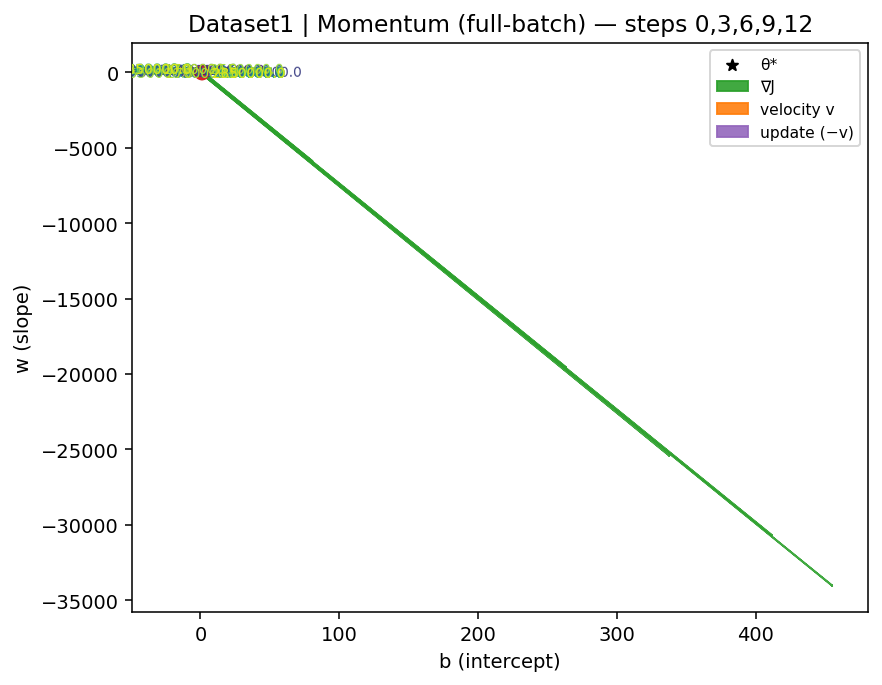

[ε=0.001] Avg steps to converge — Dataset1
  Vanilla GD (full-batch): 100000.0 ± 0.0  (min=100000, max=100000)
  Vanilla SGD (bs=1):      100000.0 ± 0.0  (min=100000, max=100000)
  Momentum GD (full-batch):166.4 ± 6.1  (min=165, max=193)
  Momentum SGD (bs=1):     100000.0 ± 0.0  (min=100000, max=100000)


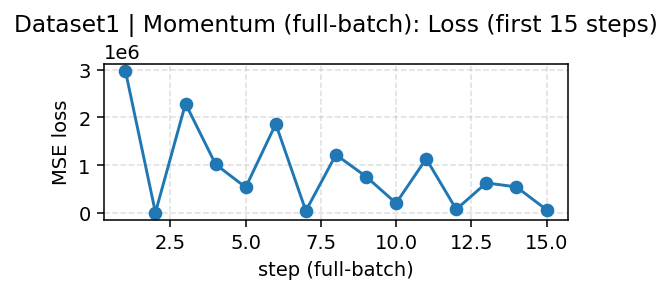

In [8]:

X1, y1 = make_dataset_1()
theta_star_1 = true_minimizer(X1, y1)
print(f"Dataset1 θ* = [{theta_star_1[0].item():.6f}, {theta_star_1[1].item():.6f}]")


mb_path_1, mb_loss_1, mb_steps_1, mb_snaps_1 = gd_momentum_full_batch(
    X1, y1, theta_star_1, lr=LR_MOM_GD, mu=MU, log_steps=EPOCHS_SHOW
)
contour_with_vectors(
    X1, y1, theta_star_1, mb_snaps_1,
    title="Dataset1 | Momentum (full-batch)",
    fname="Dataset1_momentum_vectors.png"
)

m_gd, s_gd, mn_gd, mx_gd = avg_steps(gd_full_batch, X1, y1, theta_star_1, lr=LR_GD, log_steps=1)
m_sg, s_sg, mn_sg, mx_sg = avg_steps(sgd, X1, y1, theta_star_1, lr=LR_SGD, log_epochs=1, seed=111)
m_mg, s_mg, mn_mg, mx_mg = avg_steps(gd_momentum_full_batch, X1, y1, theta_star_1, lr=LR_MOM_GD, mu=MU, log_steps=1)
m_msg, s_msg, mn_msg, mx_msg = avg_steps(sgd_momentum, X1, y1, theta_star_1, lr=LR_MOM_SGD, mu=MU, log_epochs=1, seed=222)

print(f"[ε={EPS}] Avg steps to converge — Dataset1")
print(f"  Vanilla GD (full-batch): {m_gd:.1f} ± {s_gd:.1f}  (min={mn_gd}, max={mx_gd})")
print(f"  Vanilla SGD (bs=1):      {m_sg:.1f} ± {s_sg:.1f}  (min={mn_sg}, max={mx_sg})")
print(f"  Momentum GD (full-batch):{m_mg:.1f} ± {s_mg:.1f}  (min={mn_mg}, max={mx_mg})")
print(f"  Momentum SGD (bs=1):     {m_msg:.1f} ± {s_msg:.1f}  (min={mn_msg}, max={mx_msg})")

plt.figure(figsize=(4,2.2))
plt.plot(range(1, len(mb_loss_1)+1), mb_loss_1, marker='o')
plt.xlabel("step (full-batch)")
plt.ylabel("MSE loss")
plt.title(f"Dataset1 | Momentum (full-batch): Loss (first {EPOCHS_SHOW} steps)")
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTDIR / "Dataset1_momentum_loss.png", dpi=150)
plt.show()


Momentum-SGD steps (rep run): 100000


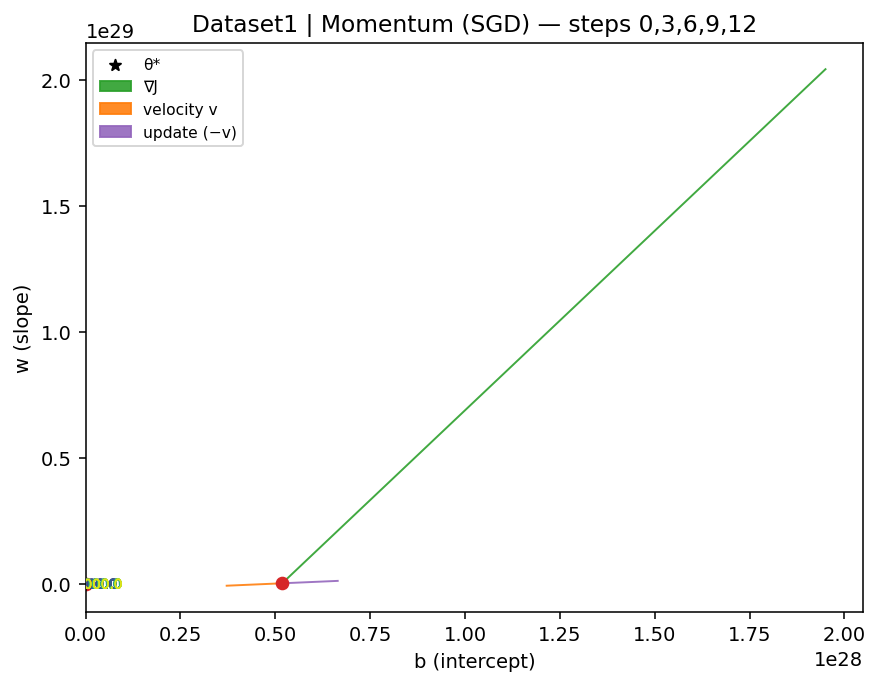

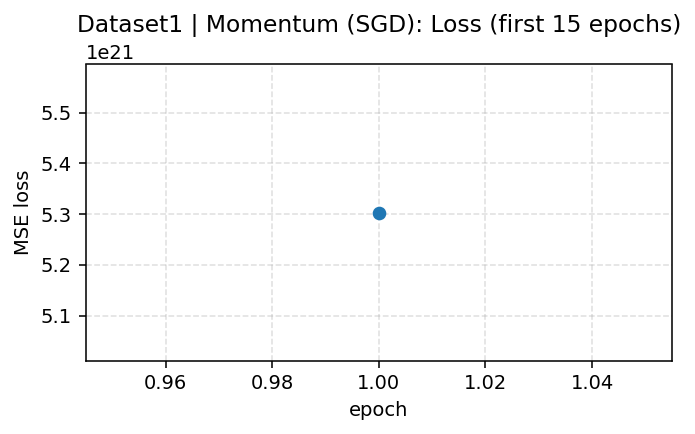

In [ ]:

ms_path_1, ms_loss_1, ms_steps_1, ms_snaps_1 = sgd_momentum(
    X1, y1, theta_star_1,
    lr=LR_MOM_SGD, mu=MU,
    log_epochs=EPOCHS_SHOW,
    seed=456
)
print(f"Momentum-SGD steps (rep run): {ms_steps_1}")


contour_with_vectors(
    X1, y1, theta_star_1, ms_snaps_1,
    title="Dataset1 | Momentum (SGD)",
    fname="Dataset1_momentumSGD_vectors.png"
)


plt.figure(figsize=(4,3.2))
plt.plot(range(1, len(ms_loss_1)+1), ms_loss_1, marker='o')
plt.xlabel("epoch")                   # one point per epoch boundary
plt.ylabel("MSE loss")
plt.title(f"Dataset1 | Momentum (SGD): Loss (first {EPOCHS_SHOW} epochs)")
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTDIR / "Dataset1_momentumSGD_loss.png", dpi=150)
plt.show()


Dataset2 θ* = [3.950706, 2.682469]


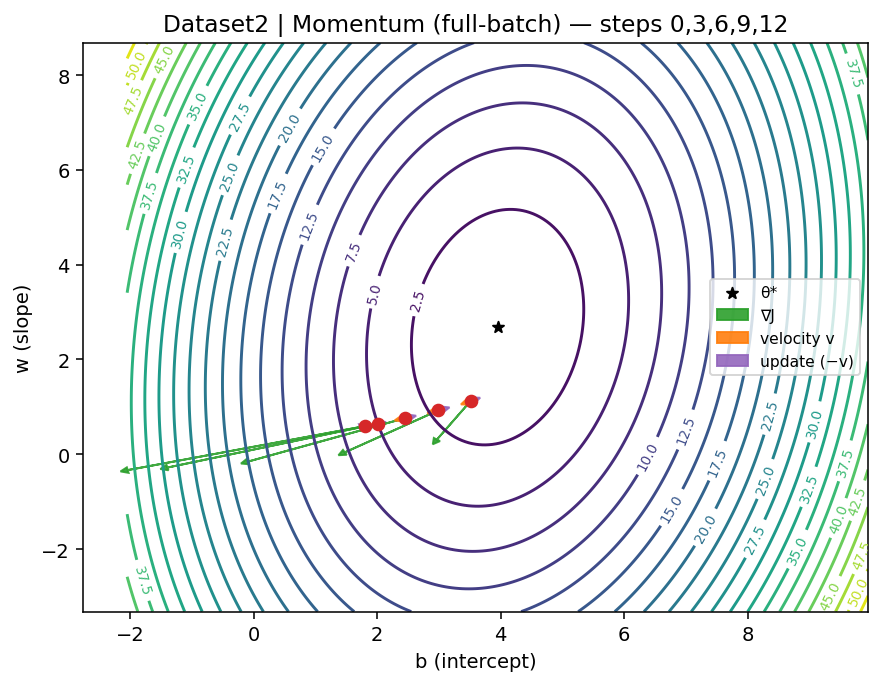

[ε=0.001] Avg steps to converge — Dataset2
  Vanilla GD (full-batch): 1288.7 ± 56.0  (min=1104, max=1359)
  Vanilla SGD (bs=1):      15142.6 ± 19789.5  (min=644, max=83615)
  Momentum GD (full-batch):154.8 ± 10.0  (min=137, max=170)
  Momentum SGD (bs=1):     68426.0 ± 37910.3  (min=2705, max=100000)


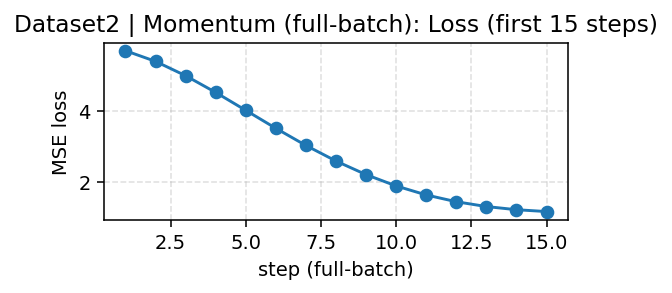

In [10]:
X2, y2 = make_dataset_2()
theta_star_2 = true_minimizer(X2, y2)
print(f"Dataset2 θ* = [{theta_star_2[0].item():.6f}, {theta_star_2[1].item():.6f}]")


mb_path_2, mb_loss_2, mb_steps_2, mb_snaps_2 = gd_momentum_full_batch(
    X2, y2, theta_star_2, lr=LR_MOM_GD, mu=MU, log_steps=EPOCHS_SHOW
)
contour_with_vectors(
    X2, y2, theta_star_2, mb_snaps_2,
    title="Dataset2 | Momentum (full-batch)",
    fname="Dataset2_momentum_vectors.png"
)


m_gd, s_gd, mn_gd, mx_gd = avg_steps(gd_full_batch, X2, y2, theta_star_2, lr=LR_GD, log_steps=1)
m_sg, s_sg, mn_sg, mx_sg = avg_steps(sgd, X2, y2, theta_star_2, lr=LR_SGD, log_epochs=1, seed=111)
m_mg, s_mg, mn_mg, mx_mg = avg_steps(gd_momentum_full_batch, X2, y2, theta_star_2, lr=LR_MOM_GD, mu=MU, log_steps=1)
m_msg, s_msg, mn_msg, mx_msg = avg_steps(sgd_momentum, X2, y2, theta_star_2, lr=LR_MOM_SGD, mu=MU, log_epochs=1, seed=222)

print(f"[ε={EPS}] Avg steps to converge — Dataset2")
print(f"  Vanilla GD (full-batch): {m_gd:.1f} ± {s_gd:.1f}  (min={mn_gd}, max={mx_gd})")
print(f"  Vanilla SGD (bs=1):      {m_sg:.1f} ± {s_sg:.1f}  (min={mn_sg}, max={mx_sg})")
print(f"  Momentum GD (full-batch):{m_mg:.1f} ± {s_mg:.1f}  (min={mn_mg}, max={mx_mg})")
print(f"  Momentum SGD (bs=1):     {m_msg:.1f} ± {s_msg:.1f}  (min={mn_msg}, max={mx_msg})")


plt.figure(figsize=(4,2.2))
plt.plot(range(1, len(mb_loss_2)+1), mb_loss_2, marker='o')
plt.xlabel("step (full-batch)")
plt.ylabel("MSE loss")
plt.title(f"Dataset2 | Momentum (full-batch): Loss (first {EPOCHS_SHOW} steps)")
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTDIR / "Dataset2_momentum_loss.png", dpi=150)
plt.show()


Momentum-SGD steps (rep run): 22623


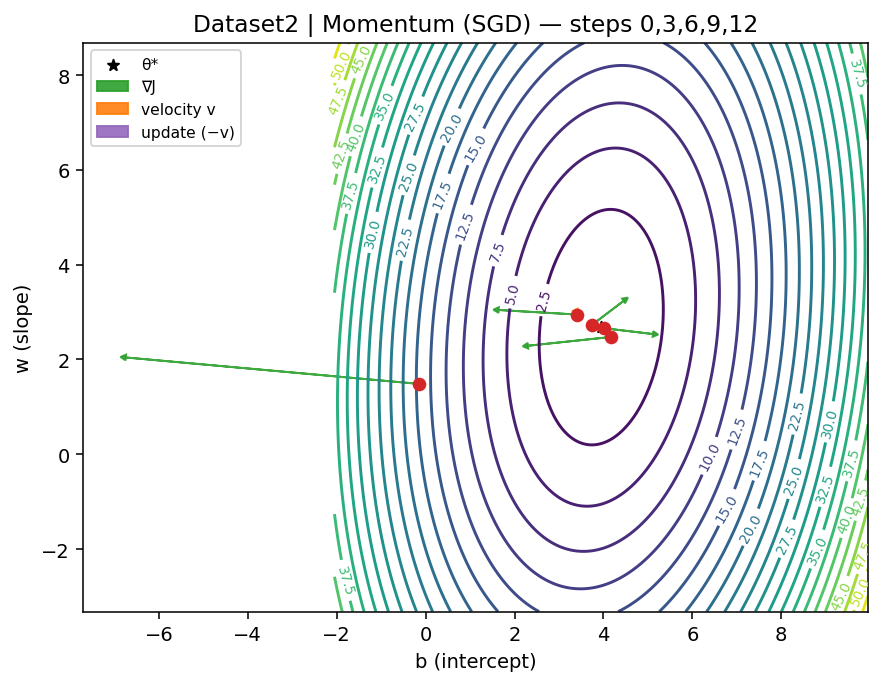

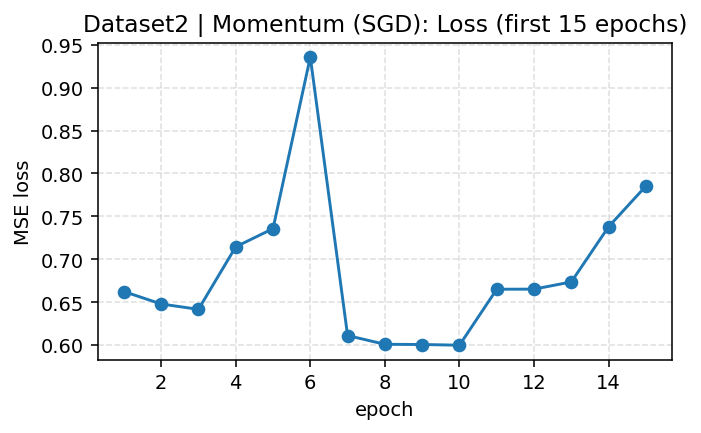

In [ ]:
ms_path_2, ms_loss_2, ms_steps_2, ms_snaps_2 = sgd_momentum(
    X2, y2, theta_star_2,
    lr=LR_MOM_SGD, mu=MU,
    log_epochs=EPOCHS_SHOW,
    seed=456
)
print(f"Momentum-SGD steps (rep run): {ms_steps_2}")


contour_with_vectors(
    X2, y2, theta_star_2, ms_snaps_2,
    title="Dataset2 | Momentum (SGD)",
    fname="Dataset2_momentumSGD_vectors.png"
)


plt.figure(figsize=(5,3.2))
plt.plot(range(1, len(ms_loss_2)+1), ms_loss_2, marker='o')
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title(f"Dataset2 | Momentum (SGD): Loss (first {EPOCHS_SHOW} epochs)")
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTDIR / "Dataset2_momentumSGD_loss.png", dpi=150)
plt.show()